Loaded 1010069 simulation rows
Fitting 2D trigger efficiency model...
  Using physical default: efficiency decreases away from 90 deg horizon.
  Primary fit converged: params = [-8.46974854e-01 -2.21613586e-10  2.65058069e+00  8.59979447e-02
  6.28080832e+00  1.21108100e-01]
  Primary param errors: [0.4124869  0.22868778 0.14869181 0.1051765  0.16484021 0.0927979 ]
  Primary weighted chi2: 15.6687
    near lower: [False False False False False False]
    near upper: [False  True False False False False]
  Relaxed fit converged: params = [-8.47005096e-01 -1.56356140e-10  2.65058764e+00  8.59933184e-02
  6.28079664e+00  1.21109517e-01]
  Relaxed param errors: [0.41247492 0.2286883  0.14869258 0.10517898 0.16483734 0.09279922]
  Relaxed weighted chi2: 15.6687
    near lower: [False False False False False False]
    near upper: [False  True False False False False]
  Using relaxed-bounds fit (less saturation with comparable chi2).
  Fitted mean trend on |90-theta| axis: decreases away fro

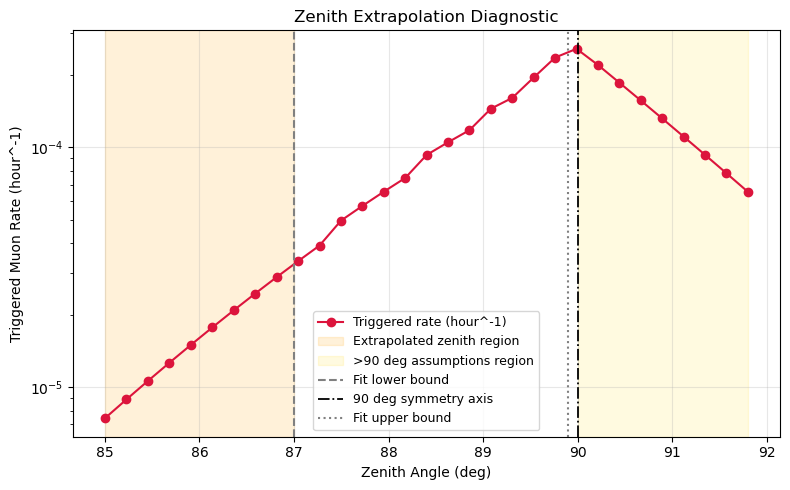


Running 50 bootstrap iterations with 16 workers...
  Using physical default: efficiency decreases away from 90 deg horizon.
  Using physical default: efficiency decreases away from 90 deg horizon.
  Primary fit converged: params = [ 5.75481616 -4.29026799  2.24116531 -0.07005841  6.93594096  0.09531151]
  Primary param errors: [0.50931864 0.35275226 0.03180553 0.03292956 0.01761277 0.01667574]
  Primary weighted chi2: 6.2672
  Fitted mean trend on |90-theta| axis: decreases away from 90 deg (mean eps @ 89.90 deg=2.1413e-02, @ 87.00 deg=2.2343e-03)
  Primary fit converged: params = [ 4.02241788 -3.05995636  2.24639579 -0.05174337  6.93248476  0.08153592]

  Primary param errors: [0.48546038 0.32141995 0.03961826 0.04128376 0.02247496 0.02122132]
  Primary weighted chi2: 8.9144
  Fitted mean trend on |90-theta| axis: decreases away from 90 deg (mean eps @ 89.90 deg=2.1106e-02, @ 87.00 deg=3.1265e-03)
  Using physical default: efficiency decreases away from 90 deg horizon.  Primary fit c

In [4]:
#Analysis code for fitting trigger efficiency and zenith trend from simulation data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import beta as beta_dist
from scipy.interpolate import interp1d
from concurrent.futures import ProcessPoolExecutor, as_completed
import os, sys, math, warnings

plt.rcParams['text.usetex'] = False

# -- Configuration -------------------------------------------------------------
PE_THRESHOLD = 20
N_BOOTSTRAP = 50
CI_LEVEL = 0.99
SEEDS = [1, 2, 3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"
H_OBS_M = 2944
R_MAX_CM = 10000
N_WORKERS = min(os.cpu_count(), 16)
N_H_SPECTRUM = 50  # smaller than 100 for faster MCEq solve in zenith loop
USE_SPECTRUM_CACHE = True
SPECTRUM_CACHE_PATH = 'mceq_spectra_cache_fit.npz'
# Optional zenith-trend constraint for epsilon_0(E,theta):
#   None: unconstrained (data decides)
#   'increase': efficiency should increase with zenith
#   'decrease': efficiency should decrease with zenith
ZENITH_TREND_CONSTRAINT = None
# Zenith fit axis:
#   'horizon_distance_monotone' fits against |90-theta| and applies
#   a monotonic decrease away from the horizon by default.
#   'raw_theta' keeps the previous theta-axis behavior.
ZENITH_FIT_AXIS_MODE = 'horizon_distance_monotone'
# Fit is constrained by simulation coverage, evaluation can extend below fit range.
ZENITH_FIT_MIN = 87.0
ZENITH_FIT_MAX = 89.9
ZENITH_EVAL_MIN = 85.0
ZENITH_EVAL_MAX = 91.8
N_ZEN_BINS_FIT = 11
N_ZEN_BINS_EVAL = 31
# -- MCEq setup ---------------------------------------------------------------
os.environ["MCEQ_LOG_LEVEL"] = "50"
import logging
logging.disable(logging.CRITICAL)
import MCEq.config as config
config.kernel_config = 'MKL'
config.e_min = 0.16  # GeV
E_max = 1e9         # GeV
config.integrator = 'euler'
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
from MCEq.core import MCEqRun
import crflux.models as pm
from MCEq.geometry.geometry import EarthGeometry
mceq = MCEqRun(
    interaction_model='SIBYLL23C',
    primary_model=(pm.GlobalSplineFitBeta, None),
    theta_deg=0.,
    density_model=("CORSIKA", ('USStd', None)),
)
earth_geom = EarthGeometry()
sys.stdout = old_stdout
logging.disable(logging.NOTSET)
def to_1e(val):
    exp = int(math.log10(val))
    coeff = val / 10**exp
    return f"{coeff:g}e{exp}"
    
E_grid = mceq.e_grid
E_sim = E_grid[(E_grid >= 1e3) & (E_grid <= 1e6)]
energy_strings = [to_1e(e) for e in E_sim]
e_bin_edges = np.logspace(3, 6, 31)
# -- Load simulation data -----------------------------------------------------



def load_scan(csv_path):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(csv_path)
    df = pd.read_csv(csv_path)
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df




dfs = []
for energy_str in energy_strings:
    for seed in SEEDS:
        csv_path = (
            f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
            f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv"
        )
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_GeV"] = float(energy_str)
            dfs.append(df_tmp)
        except Exception as e:
            print(f"  Warning: E={energy_str} seed={seed}: {e}")

if len(dfs) == 0:
    raise RuntimeError("No simulation CSVs were loaded.")

df_all = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df_all)} simulation rows")

# ============================================================================
# STEP 1: Smooth 2D trigger fit epsilon_0(E, theta)
# ============================================================================


cos_zen_fit = np.linspace(np.cos(np.radians(ZENITH_FIT_MIN)), np.cos(np.radians(ZENITH_FIT_MAX)), N_ZEN_BINS_FIT)
zen_bin_edges = np.degrees(np.arccos(cos_zen_fit))

ec = 0.5 * (np.log10(e_bin_edges[:-1]) + np.log10(e_bin_edges[1:]))
zc = 0.5 * (zen_bin_edges[:-1] + zen_bin_edges[1:])

def map_zenith_for_fit(theta_deg):
    theta_arr = np.asarray(theta_deg, dtype=float)
    if ZENITH_FIT_AXIS_MODE == 'horizon_distance_monotone':
        return np.abs(90.0 - theta_arr)
    return theta_arr


fit_axis_centers = map_zenith_for_fit(zc)
theta_ref = float(np.mean(fit_axis_centers))
theta_scale = float(np.std(fit_axis_centers)) if float(np.std(fit_axis_centers)) > 0 else 1.0


def trigger_model_2d(X, a, b, c, d, e, f):
    """2D sigmoid in log10(E) with zenith-dependent parameters."""
    logE, theta = X
    theta_fit = map_zenith_for_fit(theta)
    theta_n = (theta_fit - theta_ref) / theta_scale
    # Smoothly bounded plateau in (0,1) to avoid hard-clip degeneracy.
    a_max = 1.0 / (1.0 + np.exp(-(a + b * theta_n)))
    k = np.clip(c + d * theta_n, 1e-3, None)
    E_mid = e + f * theta_n
    return np.clip(a_max / (1.0 + np.exp(-k * (logE - E_mid))), 1e-15, 1.0)


def build_fit_data(df, e_edges, z_edges):
    n_e = len(e_edges) - 1
    n_z = len(z_edges) - 1
    ec_local = 0.5 * (np.log10(e_edges[:-1]) + np.log10(e_edges[1:]))
    zc_local = 0.5 * (z_edges[:-1] + z_edges[1:])

    logE_pts, zen_pts, eff_pts, wts = [], [], [], []

    for i in range(n_e):
        for j in range(n_z):
            mask = (
                (df["energy_GeV"] >= e_edges[i])
                & (df["energy_GeV"] < e_edges[i + 1])
                & (df["zen"] >= z_edges[j])
                & (df["zen"] < z_edges[j + 1])
            )
            subset = df[mask]
            n_total = len(subset)
            if n_total == 0:
                continue

            k_det = int(subset["detected"].sum())
            if k_det > 0:
                eff = k_det / n_total
                w = np.sqrt(n_total)
            else:
                eff = beta_dist.ppf(0.84, 1, n_total)
                w = np.sqrt(n_total) * 0.3

            logE_pts.append(ec_local[i])
            zen_pts.append(zc_local[j])
            eff_pts.append(eff)
            wts.append(max(w, 1e-6))

    return (
        np.array(logE_pts),
        np.array(zen_pts),
        np.array(eff_pts),
        np.array(wts),
    )


def build_bin_diagnostics(df, e_edges, z_edges):
    n_e = len(e_edges) - 1
    n_z = len(z_edges) - 1
    counts = np.zeros((n_e, n_z), dtype=int)
    detects = np.zeros((n_e, n_z), dtype=int)
    has_data = np.zeros((n_e, n_z), dtype=bool)

    for i in range(n_e):
        for j in range(n_z):
            mask = (
                (df["energy_GeV"] >= e_edges[i])
                & (df["energy_GeV"] < e_edges[i + 1])
                & (df["zen"] >= z_edges[j])
                & (df["zen"] < z_edges[j + 1])
            )
            n_total = int(mask.sum())
            counts[i, j] = n_total
            if n_total > 0:
                has_data[i, j] = True
                detects[i, j] = int(df.loc[mask, "detected"].sum())

    return has_data, detects, counts


def fit_trigger_efficiency(df, e_edges, z_edges):
    logE_pts, zen_pts, eff_pts, wts = build_fit_data(df, e_edges, z_edges)

    if len(eff_pts) < 8:
        raise RuntimeError("Insufficient points to fit 2D trigger model.")

    sigma = 1.0 / wts
    p0 = [4.0, 0.0, 3.0, 0.0, 4.2, 0.0]

    # Base bounds: keep model numerically stable while letting data set zenith trend.
    bounds_lo = [-6.0, -5.0, 0.05, -5.0, 2.0, -3.0]
    bounds_hi = [6.0, 5.0, 30.0, 5.0, 8.0, 3.0]

    # Relaxed bounds used only if the primary fit saturates at limits.
    relaxed_lo = [-8.0, -8.0, 0.01, -8.0, 1.5, -5.0]
    relaxed_hi = [8.0, 8.0, 40.0, 8.0, 9.0, 5.0]

    # Optional trend enforcement when desired by analysis intent.
    trend_mode = ZENITH_TREND_CONSTRAINT
    if trend_mode is None and ZENITH_FIT_AXIS_MODE == 'horizon_distance_monotone':
        trend_mode = 'decrease'
        print('  Using physical default: efficiency decreases away from 90 deg horizon.')
    if trend_mode == 'increase':
        # Increasing efficiency with zenith: higher plateau (b>=0), lower midpoint (f<=0).
        bounds_lo[1] = 0.0
        bounds_hi[5] = 0.0
        relaxed_lo[1] = 0.0
        relaxed_hi[5] = 0.0
    elif trend_mode == 'decrease':
        # Decreasing efficiency with zenith: lower plateau (b<=0), higher midpoint (f>=0).
        bounds_hi[1] = 0.0
        bounds_lo[5] = 0.0
        relaxed_hi[1] = 0.0
        relaxed_lo[5] = 0.0

    def _fit_once(p0_local, lo, hi, label):
        popt_local, pcov_local = curve_fit(
            trigger_model_2d,
            (logE_pts, zen_pts),
            eff_pts,
            p0=p0_local,
            sigma=sigma,
            bounds=(lo, hi),
            maxfev=30000,
            method='trf'
        )
        pred = trigger_model_2d((logE_pts, zen_pts), *popt_local)
        chi2 = float(np.sum(((eff_pts - pred) / sigma) ** 2))
        span = np.array(hi) - np.array(lo)
        rel = (popt_local - np.array(lo)) / np.maximum(span, 1e-12)
        near_lo = rel < 0.02
        near_hi = rel > 0.98
        print(f"  {label} fit converged: params = {popt_local}")
        print(f"  {label} param errors: {np.sqrt(np.diag(pcov_local))}")
        print(f"  {label} weighted chi2: {chi2:.4f}")
        if np.any(near_lo | near_hi):
            print(f"  Warning: {label} fit has params near bounds")
            print(f"    near lower: {near_lo}")
            print(f"    near upper: {near_hi}")
        return popt_local, pcov_local, chi2, near_lo, near_hi

    try:
        popt, pcov, chi2_base, near_lo, near_hi = _fit_once(p0, bounds_lo, bounds_hi, 'Primary')

        # If saturated near bounds, retry with relaxed bounds and keep the better fit.
        if np.any(near_lo | near_hi):
            try:
                popt_r, pcov_r, chi2_r, near_lo_r, near_hi_r = _fit_once(popt, relaxed_lo, relaxed_hi, 'Relaxed')
                n_near_base = int(np.sum(near_lo | near_hi))
                n_near_relaxed = int(np.sum(near_lo_r | near_hi_r))
                if (chi2_r <= chi2_base * 1.05) and (n_near_relaxed <= n_near_base):
                    print('  Using relaxed-bounds fit (less saturation with comparable chi2).')
                    popt, pcov = popt_r, pcov_r
                else:
                    print('  Keeping primary fit (relaxed fit not clearly better).')
            except RuntimeError as exc_r:
                print(f"  Relaxed refit failed: {exc_r}. Keeping primary fit.")

        # Report the fitted zenith trend across the simulation energy window.
        probe_logE = np.linspace(np.log10(e_edges[0]), np.log10(e_edges[-1]), 200)
        zen_lo = float(z_edges[0])
        zen_hi = float(z_edges[-1])
        eps_lo = trigger_model_2d((probe_logE, np.full_like(probe_logE, zen_lo)), *popt)
        eps_hi = trigger_model_2d((probe_logE, np.full_like(probe_logE, zen_hi)), *popt)
        mean_lo = float(np.mean(eps_lo))
        mean_hi = float(np.mean(eps_hi))
        if ZENITH_FIT_AXIS_MODE == 'horizon_distance_monotone':
            trend_txt = 'decreases away from 90 deg' if mean_lo < mean_hi else 'increases away from 90 deg'
            print(f"  Fitted mean trend on |90-theta| axis: {trend_txt} (mean eps @ {zen_hi:.2f} deg={mean_hi:.4e}, @ {zen_lo:.2f} deg={mean_lo:.4e})")
        else:
            trend_txt = 'increases with zenith' if mean_hi > mean_lo else 'decreases with zenith'
            print(f"  Fitted mean trend: {trend_txt} (mean eps @ {zen_lo:.2f} deg={mean_lo:.4e}, @ {zen_hi:.2f} deg={mean_hi:.4e})")
    except RuntimeError as exc:
        warnings.warn(f"Fit failed: {exc}. Using initial guess.")
        popt = np.array(p0, dtype=float)

    def eff_func(pts):
        pts = np.atleast_2d(pts)
        theta = pts[:, 1]
        eps_main = trigger_model_2d((pts[:, 0], theta), *popt)
        if ZENITH_FIT_AXIS_MODE == 'horizon_distance_monotone':
            # Enforce exact mirror symmetry: eps(theta) = eps(180-theta).
            eps_mirror = trigger_model_2d((pts[:, 0], 180.0 - theta), *popt)
            return 0.5 * (eps_main + eps_mirror)
        return eps_main

    return eff_func, popt


print("Fitting 2D trigger efficiency model...")
interp_center, fit_params_nom = fit_trigger_efficiency(df_all, e_bin_edges, zen_bin_edges)
has_data_grid, detect_grid, counts_grid = build_bin_diagnostics(df_all, e_bin_edges, zen_bin_edges)

# Predicted efficiency on bin centers for diagnostics/plotting.
logE_2d_c, zen_2d_c = np.meshgrid(ec, zc, indexing='ij')
pts_c = np.column_stack([logE_2d_c.ravel(), zen_2d_c.ravel()])
eff_center = interp_center(pts_c).reshape(logE_2d_c.shape)

# Symmetry diagnostic for the fitted efficiency around 90 deg.
if ZENITH_FIT_AXIS_MODE == 'horizon_distance_monotone' and ZENITH_EVAL_MAX > 90.0:
    max_delta = min(90.0 - ZENITH_EVAL_MIN, ZENITH_EVAL_MAX - 90.0)
    if max_delta > 0:
        deltas = np.linspace(0.0, max_delta, 5)
        probe_logE = np.linspace(np.log10(e_bin_edges[0]), np.log10(e_bin_edges[-1]), 120)
        max_abs_diff = 0.0
        for dlt in deltas:
            theta_lo = 90.0 - dlt
            theta_hi = 90.0 + dlt
            eps_lo = interp_center(np.column_stack([probe_logE, np.full_like(probe_logE, theta_lo)]))
            eps_hi = interp_center(np.column_stack([probe_logE, np.full_like(probe_logE, theta_hi)]))
            local_diff = float(np.max(np.abs(eps_lo - eps_hi)))
            max_abs_diff = max(max_abs_diff, local_diff)
        print(f"Symmetry check around 90 deg: max |eps(90-d)-eps(90+d)| = {max_abs_diff:.3e}")

# ============================================================================
# STEP 2: Radial dependence f(r)
# ============================================================================

r_profile_cm = np.linspace(0, R_MAX_CM, 100)
m_slope = (0.02 - 0.005) / (0 - 500)
b_intercept = 0.02
trigger_rate_r = np.clip(m_slope * r_profile_cm + b_intercept, 0, None)
trigger_rate_r_normalized = trigger_rate_r / np.max(trigger_rate_r)

f_r_interp = interp1d(r_profile_cm, trigger_rate_r_normalized, kind='linear', bounds_error=False, fill_value=0.0)

dr_cm = r_profile_cm[1] - r_profile_cm[0]
A_geom_cm2 = 2 * np.pi * np.trapezoid(trigger_rate_r_normalized * r_profile_cm, dx=dr_cm)
R_MAX_M = R_MAX_CM / 100.0
print(f"Geometric effective area factor: {A_geom_cm2:.1f} cm^2 = {A_geom_cm2/1e4:.4f} m^2")


def compute_effective_area_cm2(E_arr, zenith_deg, eff_func):
    """Effective area = epsilon_0(E, theta) times geometric area."""
    # Symmetry assumption around 90 deg: eps(theta) = eps(180-theta).
    zenith_eff_deg = zenith_deg if zenith_deg <= 90.0 else (180.0 - zenith_deg)
    logE = np.log10(E_arr)
    pts = np.column_stack([logE, np.full_like(logE, zenith_eff_deg)])
    eps = eff_func(pts)
    return eps * A_geom_cm2

# ============================================================================
# STEP 3: MCEq flux x trigger efficiency -> detected muon rate
# ============================================================================

def get_spectrum(theta, Nh, mag=0, h_obs_m=H_OBS_M, h_max_m=112800.0):
    mceq.set_theta_deg(theta)
    mceq.integration_path = None
    angle_rad = np.radians(theta)
    L = earth_geom.path_len(angle_rad)
    L_grid = np.linspace(L, 0, Nh)
    H_grid = np.array([earth_geom.h(l, angle_rad) for l in (L) - L_grid])
    H_grid = H_grid[H_grid >= h_obs_m * 1e2]
    H_grid = H_grid[H_grid <= h_max_m * 1e2]
    L_grid = L_grid[-len(H_grid):]
    X_grid = mceq.density_model.h2X(H_grid)
    mceq.solve(int_grid=X_grid)
    ground_flux = (
        mceq.get_solution('total_mu-', grid_idx=-1, mag=mag)
        + mceq.get_solution('total_mu+', grid_idx=-1, mag=mag)
    )
    return ground_flux, L_grid, X_grid, H_grid


cos_zen_eval = np.linspace(np.cos(np.radians(ZENITH_EVAL_MIN)), np.cos(np.radians(ZENITH_EVAL_MAX)), N_ZEN_BINS_EVAL)
zenith_angles = np.degrees(np.arccos(cos_zen_eval))
fit_zenith_mask = (zenith_angles >= ZENITH_FIT_MIN) & (zenith_angles <= ZENITH_FIT_MAX)
extrap_below_fit_mask = zenith_angles < ZENITH_FIT_MIN
extrap_above_90_mask = zenith_angles > 90.0
extrap_zenith_mask = extrap_below_fit_mask | extrap_above_90_mask
d_theta = np.diff(zenith_angles)[0]
az_lo, az_hi = 267.0, 273.0

print("\nCaching MCEq spectra...")
E_mask = E_grid < E_max
E_masked = E_grid[E_mask]
n_zen = len(zenith_angles)
n_E_masked = int(np.sum(E_mask))

spectra_array = np.zeros((n_zen, n_E_masked))
solid_angles_array = np.zeros(n_zen)

cache_loaded = False
if USE_SPECTRUM_CACHE and os.path.exists(SPECTRUM_CACHE_PATH):
    try:
        cache = np.load(SPECTRUM_CACHE_PATH)
        z_cache = cache['zenith_angles']
        e_cache = cache['E_masked']
        s_cache = cache['spectra_array']
        sa_cache = cache['solid_angles_array']
        if np.array_equal(z_cache, zenith_angles) and np.array_equal(e_cache, E_masked):
            spectra_array = s_cache
            solid_angles_array = sa_cache
            cache_loaded = True
            print(f"  Loaded cached spectra from {SPECTRUM_CACHE_PATH}")
        else:
            print('  Cache exists but grid changed; rebuilding spectra...')
    except Exception as exc:
        print(f"  Could not load cache ({exc}); rebuilding spectra...")

if not cache_loaded:
    for i, theta in enumerate(zenith_angles):
        # Flux assumption above 90 deg: use the 90 deg spectrum.
        theta_for_flux = min(theta, 90.0)
        gf, _, _, _ = get_spectrum(theta_for_flux, N_H_SPECTRUM)
        spectra_array[i, :] = gf[E_mask]
        d_phi = np.radians(az_hi) - np.radians(az_lo)
        d_cos_theta = abs(np.cos(np.radians(theta + d_theta)) - np.cos(np.radians(theta)))
        solid_angles_array[i] = d_phi * d_cos_theta
        print(f"  theta={theta:.2f} deg cached (flux theta={theta_for_flux:.2f})")

    if USE_SPECTRUM_CACHE:
        try:
            np.savez(
                SPECTRUM_CACHE_PATH,
                zenith_angles=zenith_angles,
                E_masked=E_masked,
                spectra_array=spectra_array,
                solid_angles_array=solid_angles_array,
            )
            print(f"  Saved spectra cache to {SPECTRUM_CACHE_PATH}")
        except Exception as exc:
            print(f"  Warning: failed to save spectra cache ({exc})")


def compute_observables(eff_func):
    A_eff_sum = np.zeros(n_E_masked)
    naive_rates = np.zeros(n_zen)
    triggered_rates = np.zeros(n_zen)
    dRate_dE_total = np.zeros(n_E_masked)

    for i in range(n_zen):
        gf_masked = spectra_array[i]
        solid_angle = solid_angles_array[i]
        flux_integrated = np.trapezoid(gf_masked, E_masked)
        naive_rates[i] = flux_integrated * solid_angle * A_geom_cm2

        A_eff_cm2 = compute_effective_area_cm2(E_masked, zenith_angles[i], eff_func)
        A_eff_sum += A_eff_cm2

        integrand = gf_masked * A_eff_cm2 * solid_angle
        triggered_rates[i] = np.trapezoid(integrand, E_masked)
        dRate_dE_total += gf_masked * A_eff_cm2 * solid_angle

    A_eff_avg_m2 = (A_eff_sum / n_zen) / 1e4
    return A_eff_avg_m2, naive_rates, triggered_rates, dRate_dE_total


print("\nComputing nominal values...")
A_eff_avg_m2_nom, Total_flux_naive, Total_flux_triggered, dRate_dE_total_nom = compute_observables(interp_center)

sec_per_hour = 3600
muons_naive = np.sum(Total_flux_naive) * sec_per_hour 
muons_triggered = np.sum(Total_flux_triggered) * sec_per_hour
muons_triggered_fit = np.sum(Total_flux_triggered[fit_zenith_mask]) * sec_per_hour
muons_triggered_extrap_below = np.sum(Total_flux_triggered[extrap_below_fit_mask]) * sec_per_hour
muons_triggered_extrap = np.sum(Total_flux_triggered[extrap_zenith_mask]) * sec_per_hour
muons_triggered_extrap_above90 = np.sum(Total_flux_triggered[extrap_above_90_mask]) * sec_per_hour

print(f"\n{'=' * 70}")
print(f"Naive muons/hour (geometric area):      {muons_naive:.4f}")
print(f"Triggered muons/hour (fit model):       {muons_triggered:.4f}")
print(f"Overall trigger efficiency:            {muons_triggered / muons_naive:.6f}")
print(f"Triggered from fit-covered zenith (>= {ZENITH_FIT_MIN:.1f} deg): {muons_triggered_fit:.4f}")
print(f"Triggered from extrapolated zenith (< {ZENITH_FIT_MIN:.1f} deg): {muons_triggered_extrap_below:.4f}")
print(f"Triggered from >90 deg zenith (symmetry+flux clamp): {muons_triggered_extrap_above90:.4f}")
print(f"Total triggered from extrapolated regions: {muons_triggered_extrap:.4f}")
print(f"{'=' * 70}")

# Diagnostic plot to show where rates are extrapolated in zenith.
plt.figure(figsize=(8, 5))
plt.plot(zenith_angles, Total_flux_triggered * sec_per_hour, 'o-', color='crimson', label='Triggered rate (hour^-1)')
if np.any(extrap_below_fit_mask):
    plt.axvspan(ZENITH_EVAL_MIN, ZENITH_FIT_MIN, color='orange', alpha=0.15, label='Extrapolated zenith region')
if np.any(extrap_above_90_mask):
    plt.axvspan(90.0, ZENITH_EVAL_MAX, color='gold', alpha=0.12, label='>90 deg assumptions region')
plt.axvline(ZENITH_FIT_MIN, color='gray', ls='--', lw=1.5, label='Fit lower bound')
plt.axvline(90.0, color='black', ls='-.', lw=1.3, label='90 deg symmetry axis')
plt.axvline(ZENITH_FIT_MAX, color='gray', ls=':', lw=1.5, label='Fit upper bound')
plt.yscale('log')
plt.xlabel('Zenith Angle (deg)')
plt.ylabel('Triggered Muon Rate (hour^-1)')
plt.title('Zenith Extrapolation Diagnostic')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('zenith_extrapolation_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# BOOTSTRAP: resample -> refit -> recompute
# ============================================================================

def _bootstrap_single(args):
    (
        seed,
        df_values,
        df_columns,
        e_edges,
        z_edges,
        E_masked_local,
        zenith_angles_local,
        spectra,
        solid_angles,
        A_geom,
        fit_params_fallback,
    ) = args

    df_boot = pd.DataFrame(df_values, columns=df_columns)
    rng_local = np.random.default_rng(seed)
    idx = rng_local.choice(len(df_boot), size=len(df_boot), replace=True)
    df_r = df_boot.iloc[idx].reset_index(drop=True)

    try:
        eff_func_b, _ = fit_trigger_efficiency(df_r, e_edges, z_edges)
    except Exception:
        def eff_func_b(pts):
            pts = np.atleast_2d(pts)
            return trigger_model_2d((pts[:, 0], pts[:, 1]), *fit_params_fallback)

    n_zen_b = len(zenith_angles_local)
    n_E_b = len(E_masked_local)
    A_eff_sum = np.zeros(n_E_b)
    triggered_rates = np.zeros(n_zen_b)
    dRate_dE_total = np.zeros(n_E_b)

    logE = np.log10(E_masked_local)
    for i in range(n_zen_b):
        # Keep bootstrap consistent with symmetry assumption around 90 deg.
        zenith_eff_deg = zenith_angles_local[i] if zenith_angles_local[i] <= 90.0 else (180.0 - zenith_angles_local[i])
        pts = np.column_stack([logE, np.full(n_E_b, zenith_eff_deg)])
        eps = eff_func_b(pts)
        A_eff_cm2 = eps * A_geom
        A_eff_sum += A_eff_cm2

        integrand = spectra[i] * A_eff_cm2 * solid_angles[i]
        triggered_rates[i] = np.trapezoid(integrand, E_masked_local)
        dRate_dE_total += spectra[i] * A_eff_cm2 * solid_angles[i]

    return (A_eff_sum / n_zen_b) / 1e4, triggered_rates, dRate_dE_total


print(f"\nRunning {N_BOOTSTRAP} bootstrap iterations with {N_WORKERS} workers...")
df_values = df_all.values
df_columns = list(df_all.columns)
rng = np.random.default_rng(42)
boot_seeds = rng.integers(0, 2**31, size=N_BOOTSTRAP)

args_list = [
    (
        boot_seeds[b],
        df_values,
        df_columns,
        e_bin_edges,
        zen_bin_edges,
        E_masked,
        zenith_angles,
        spectra_array,
        solid_angles_array,
        A_geom_cm2,
        fit_params_nom,
    )
    for b in range(N_BOOTSTRAP)
]

boot_A_eff = np.zeros((N_BOOTSTRAP, n_E_masked))
boot_dRate = np.zeros((N_BOOTSTRAP, n_E_masked))
boot_triggered = np.zeros((N_BOOTSTRAP, n_zen))

try:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {executor.submit(_bootstrap_single, args): b for b, args in enumerate(args_list)}
        done_count = 0
        for future in as_completed(futures):
            b = futures[future]
            A_eff_b, trig_b, dRate_b = future.result()
            boot_A_eff[b] = A_eff_b
            boot_triggered[b] = trig_b
            boot_dRate[b] = dRate_b
            done_count += 1
            if done_count % 50 == 0:
                print(f"  Bootstrap {done_count}/{N_BOOTSTRAP} complete")
    print(f"  Parallel bootstrap complete ({N_WORKERS} workers)")
except Exception as e:
    print(f"  Parallel failed ({e}), falling back to serial...")
    for b in range(N_BOOTSTRAP):
        if (b + 1) % 50 == 0:
            print(f"  Bootstrap {b + 1}/{N_BOOTSTRAP}")
        A_eff_b, trig_b, dRate_b = _bootstrap_single(args_list[b])
        boot_A_eff[b] = A_eff_b
        boot_triggered[b] = trig_b
        boot_dRate[b] = dRate_b

# -- Confidence intervals -----------------------------------------------------
alpha = 1 - CI_LEVEL
lo_pct = 100 * alpha / 2
hi_pct = 100 * (1 - alpha / 2)

A_eff_lo = np.percentile(boot_A_eff, lo_pct, axis=0)
A_eff_hi = np.percentile(boot_A_eff, hi_pct, axis=0)
triggered_lo = np.percentile(boot_triggered, lo_pct, axis=0)
triggered_hi = np.percentile(boot_triggered, hi_pct, axis=0)
dRate_lo = np.percentile(boot_dRate, lo_pct, axis=0)
dRate_hi = np.percentile(boot_dRate, hi_pct, axis=0)

boot_muons_triggered = np.sum(boot_triggered, axis=1) * sec_per_hour
muons_triggered_ci = np.percentile(boot_muons_triggered, [lo_pct, hi_pct])

print(f"\n{'=' * 70}")
print(f"Naive muons/hour:     {muons_naive:.4f}")
print(f"Triggered muons/hour: {muons_triggered:.4f} [{muons_triggered_ci[0]:.4f}, {muons_triggered_ci[1]:.4f}] ({CI_LEVEL*100:.0f}% CI)")
print(f"{'=' * 70}")



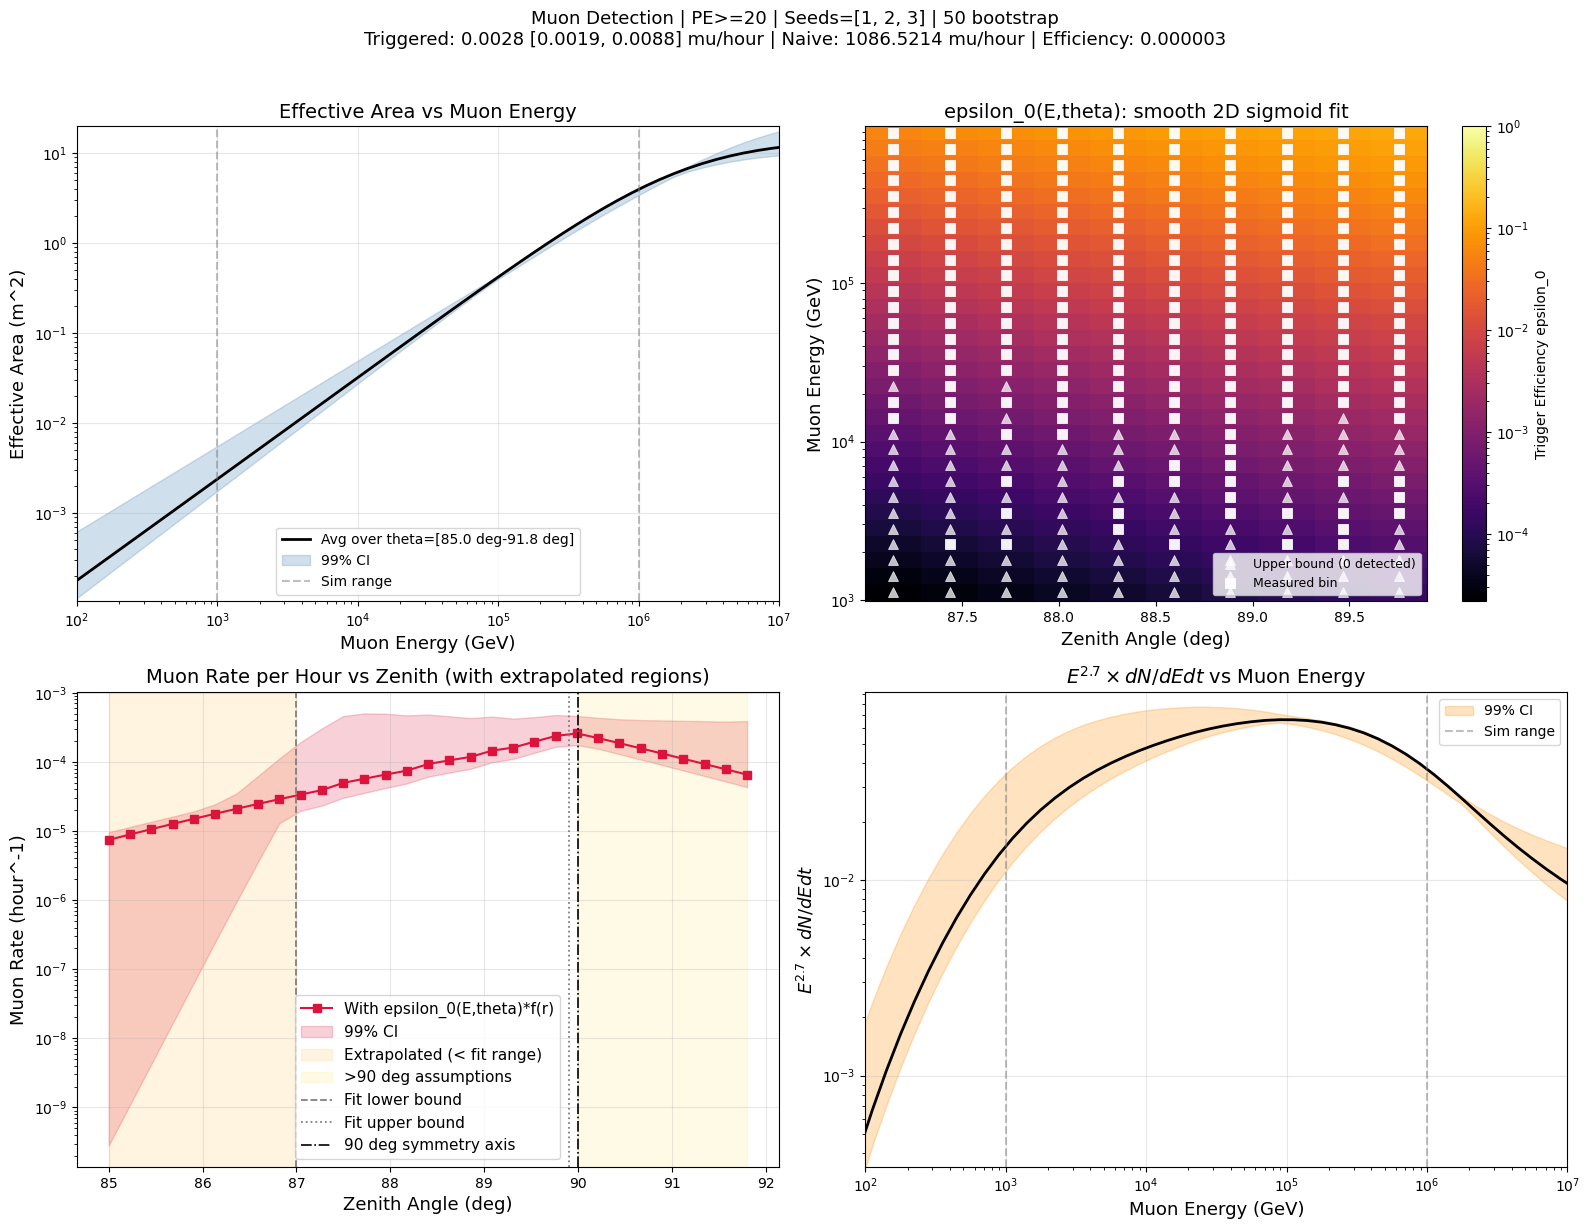

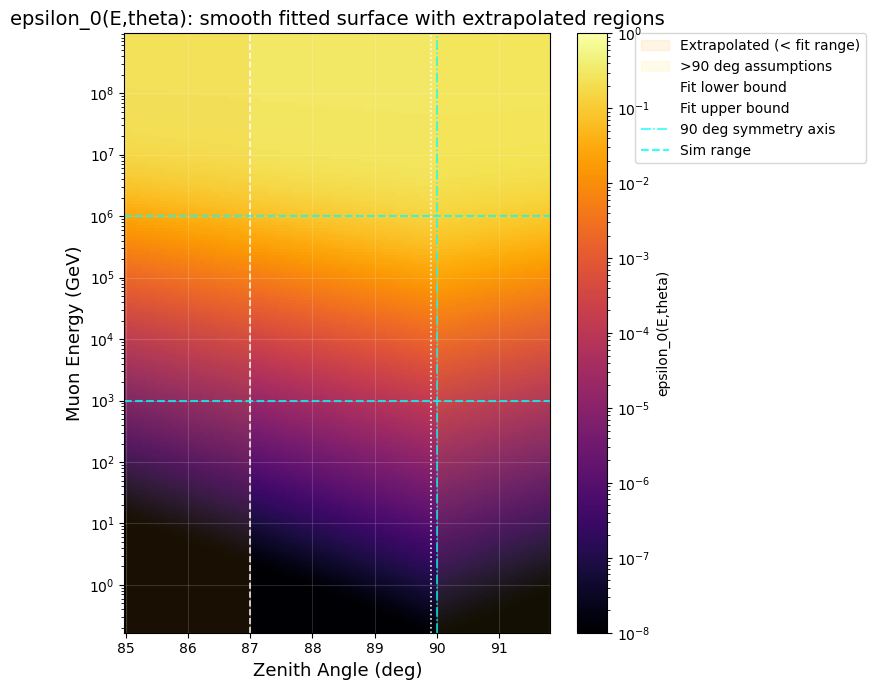

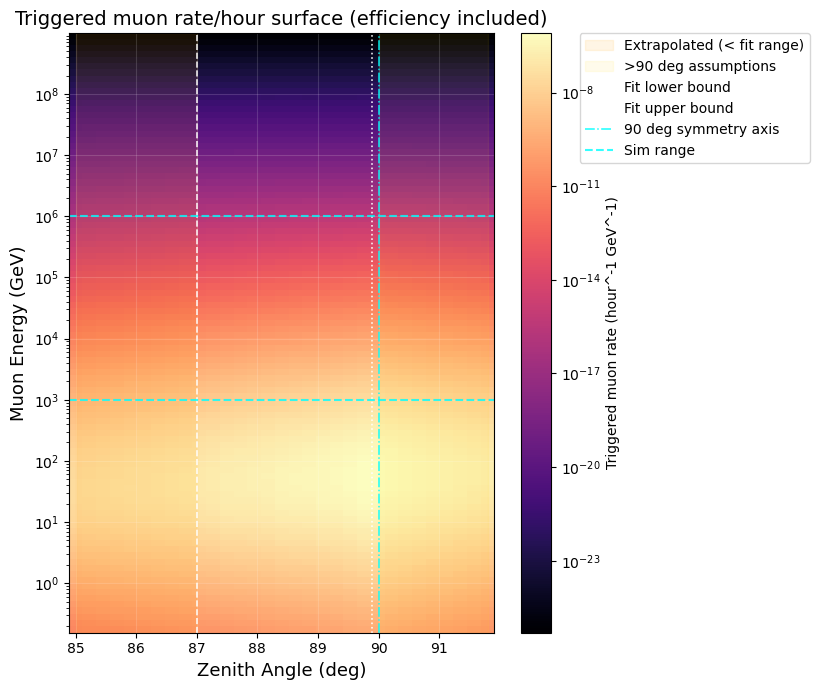

1D-slice zeniths selected (deg): [87.145 88.015 88.885 89.755]
  theta=87.15 deg: measured bins=18, upper-limit bins=12
  theta=88.02 deg: measured bins=20, upper-limit bins=10
  theta=88.89 deg: measured bins=25, upper-limit bins=5
  theta=89.76 deg: measured bins=22, upper-limit bins=8


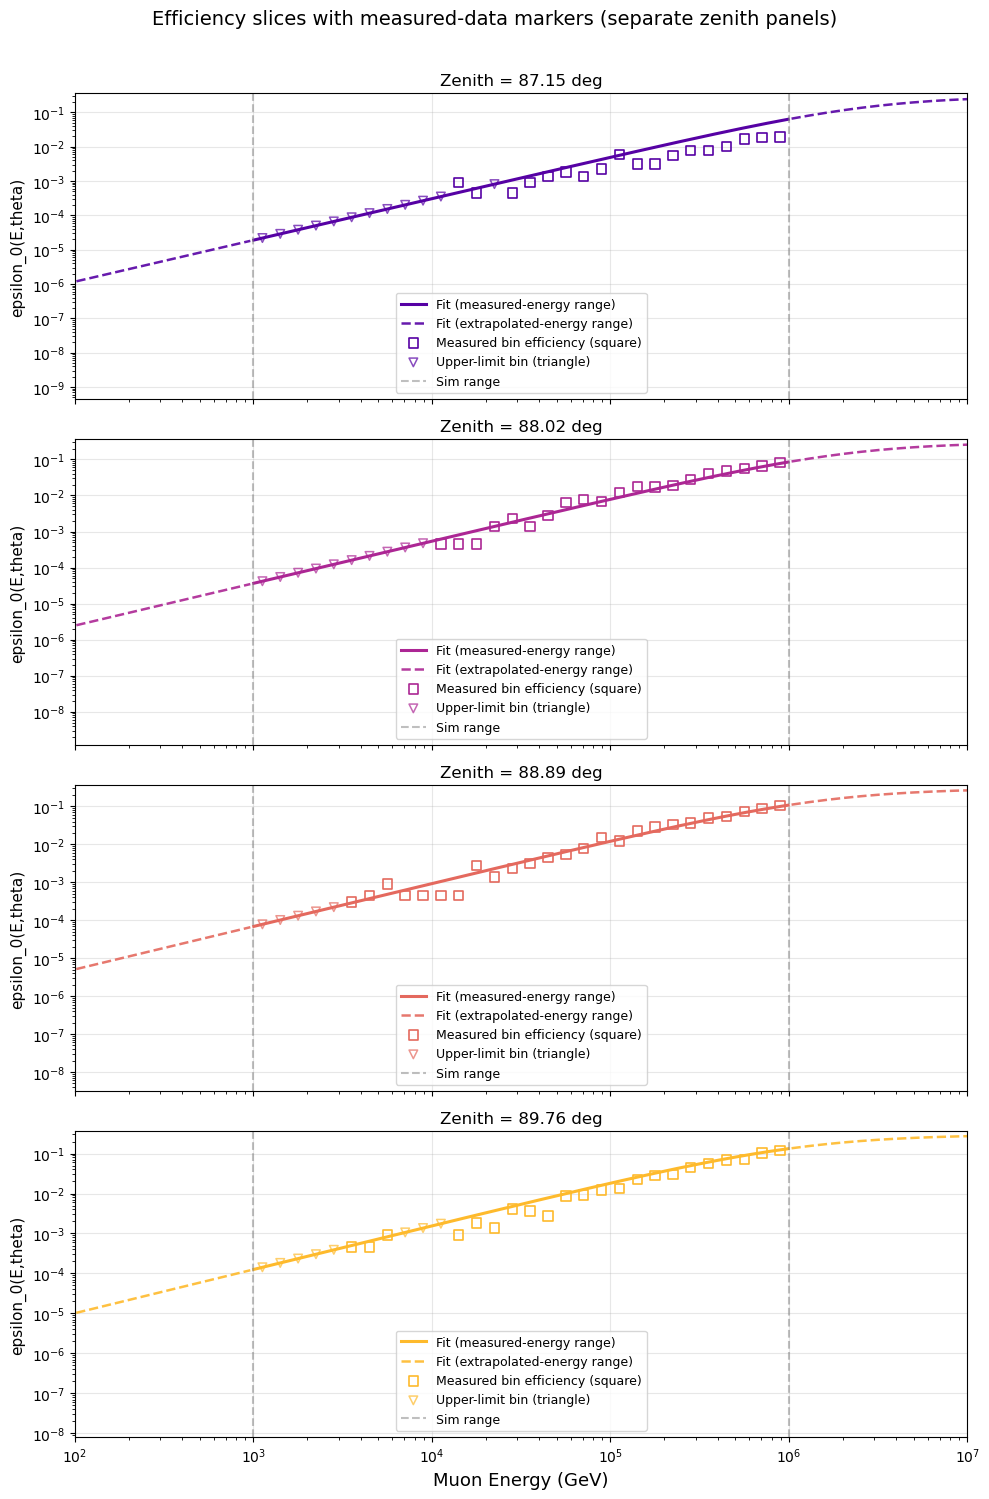

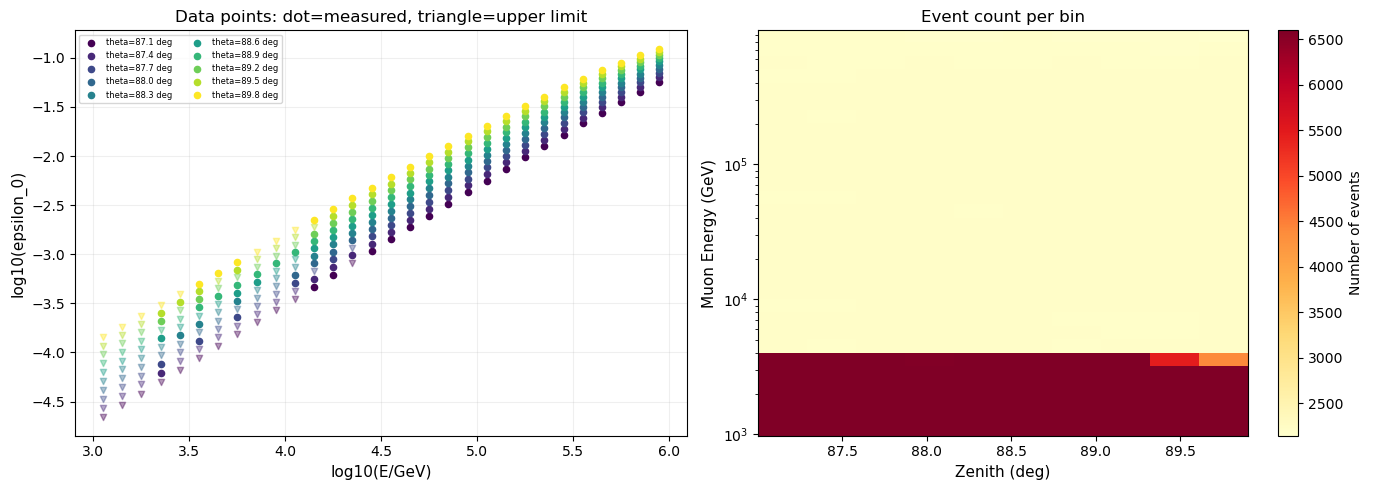

In [ ]:
#Plot analysis results
# ============================================================================
# PLOTS
# ============================================================================
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Effective Area
ax = axes[0, 0]
mask_p = A_eff_avg_m2_nom > 0
if mask_p.any():
    ax.plot(E_masked[mask_p], A_eff_avg_m2_nom[mask_p], 'k-', lw=2,
            label=f'Avg over theta=[{zenith_angles[0]:.1f} deg-{zenith_angles[-1]:.1f} deg]')
    ax.fill_between(E_masked[mask_p], A_eff_lo[mask_p], A_eff_hi[mask_p],
                    alpha=0.25, color='steelblue', label=f'{CI_LEVEL*100:.0f}% CI')
    ax.axvline(e_bin_edges[0], ls='--', color='gray', alpha=0.5, label='Sim range')
    ax.axvline(e_bin_edges[-1], ls='--', color='gray', alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e2, 1e7)
range_mask_p = mask_p & (E_masked >= 1e2) & (E_masked <= 1e7)
if np.any(range_mask_p):
    y_band_p = np.concatenate([A_eff_avg_m2_nom[range_mask_p], A_eff_lo[range_mask_p], A_eff_hi[range_mask_p]])
    y_band_p = y_band_p[np.isfinite(y_band_p) & (y_band_p > 0)]
    if y_band_p.size > 0:
        ax.set_ylim(np.min(y_band_p) * 0.8, np.max(y_band_p) * 1.2)
ax.set_xlabel('Muon Energy (GeV)', fontsize=13)
ax.set_ylabel('Effective Area (m^2)', fontsize=13)
ax.set_title('Effective Area vs Muon Energy', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Fitted 2D efficiency surface
ax = axes[0, 1]
vmin_p = np.min(eff_center[eff_center > 1e-14]) if np.any(eff_center > 1e-14) else 1e-6
im = ax.pcolormesh(zc, 10**ec, eff_center, cmap='inferno', shading='auto', norm=LogNorm(vmin=vmin_p, vmax=1.0))
plotted_measured_label = False
plotted_upper_label = False
for i in range(len(ec)):
    for j in range(len(zc)):
        if has_data_grid[i, j] and detect_grid[i, j] > 0:
            lbl = 'Measured bin' if not plotted_measured_label else None
            ax.plot(zc[j], 10**ec[i], 'ws', ms=7, mec='white', mew=0.6, alpha=0.95, label=lbl)
            plotted_measured_label = True
        elif has_data_grid[i, j] and detect_grid[i, j] == 0:
            lbl = 'Upper bound (0 detected)' if not plotted_upper_label else None
            ax.plot(zc[j], 10**ec[i], 'w^', ms=7, mec='white', mew=0.6, alpha=0.75, label=lbl)
            plotted_upper_label = True
ax.set_xlabel('Zenith Angle (deg)', fontsize=13)
ax.set_ylabel('Muon Energy (GeV)', fontsize=13)
ax.set_yscale('log')
ax.set_title('epsilon_0(E,theta): smooth 2D sigmoid fit', fontsize=14)
plt.colorbar(im, ax=ax, label='Trigger Efficiency epsilon_0')
ax.legend(fontsize=9, loc='lower right')

# Plot 3: Rate vs Zenith
ax = axes[1, 0]
ax.plot(zenith_angles, Total_flux_triggered * sec_per_hour, 's-', label='With epsilon_0(E,theta)*f(r)', color='crimson')
ax.fill_between(zenith_angles, triggered_lo * sec_per_hour, triggered_hi * sec_per_hour,
                alpha=0.2, color='crimson', label=f'{CI_LEVEL*100:.0f}% CI')
if np.any(extrap_below_fit_mask):
    ax.axvspan(ZENITH_EVAL_MIN, ZENITH_FIT_MIN, color='orange', alpha=0.12, label='Extrapolated (< fit range)')
if np.any(extrap_above_90_mask):
    ax.axvspan(90.0, ZENITH_EVAL_MAX, color='gold', alpha=0.10, label='>90 deg assumptions')
ax.axvline(ZENITH_FIT_MIN, color='gray', ls='--', lw=1.3, label='Fit lower bound')
ax.axvline(ZENITH_FIT_MAX, color='gray', ls=':', lw=1.3, label='Fit upper bound')
ax.axvline(90.0, color='black', ls='-.', lw=1.2, label='90 deg symmetry axis')
ax.set_xlabel('Zenith Angle (deg)', fontsize=13)
ax.set_ylabel('Muon Rate (hour^-1)', fontsize=13)
ax.set_title('Muon Rate per Hour vs Zenith (with extrapolated regions)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 4: E^E_magnitude * dN/(dE dt) vs Energy
ax = axes[1, 1]
mask_d = dRate_dE_total_nom > 0
E_magnitude = 1
if mask_d.any():
    y_nom = (dRate_dE_total_nom * E_masked**E_magnitude)[mask_d]
    y_lo = (dRate_lo * E_masked**E_magnitude)[mask_d]
    y_hi = (dRate_hi * E_masked**E_magnitude)[mask_d]
    ax.plot(E_masked[mask_d], y_nom, 'k-', lw=2)
    ax.fill_between(E_masked[mask_d], y_lo, y_hi,
                    alpha=0.25, color='darkorange', label=f'{CI_LEVEL*100:.0f}% CI')
    ax.axvline(e_bin_edges[0], ls='--', color='gray', alpha=0.5, label='Sim range')
    ax.axvline(e_bin_edges[-1], ls='--', color='gray', alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e2, 1e7)
range_mask_d = mask_d & (E_masked >= 1e2) & (E_masked <= 1e7)
if np.any(range_mask_d):
    y_band_d = np.concatenate([
        dRate_dE_total_nom[range_mask_d] * E_masked[range_mask_d]**E_magnitude,
        dRate_lo[range_mask_d] * E_masked[range_mask_d]**E_magnitude,
        dRate_hi[range_mask_d] * E_masked[range_mask_d]**E_magnitude,
    ])
    y_band_d = y_band_d[np.isfinite(y_band_d) & (y_band_d > 0)]
    if y_band_d.size > 0:
        ax.set_ylim(np.min(y_band_d) * 0.8, np.max(y_band_d) * 1.2)
ax.set_xlabel('Muon Energy (GeV)', fontsize=13)
ax.set_ylabel(r'$E^{' + str(E_magnitude) + r'} \times dN/dE dt$', fontsize=13)
ax.set_title(r'$E^{' + str(E_magnitude) + r'} \times dN/dE dt$ vs Muon Energy', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Muon Detection | PE>={PE_THRESHOLD} | Seeds={SEEDS} | {N_BOOTSTRAP} bootstrap\n"
    f"Triggered: {muons_triggered:.4f} [{muons_triggered_ci[0]:.4f}, {muons_triggered_ci[1]:.4f}] mu/hour | "
    f"Naive: {muons_naive:.4f} mu/hour | "
    f"Efficiency: {muons_triggered/muons_naive:.6f}",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.savefig('muon_flux_4panel.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional smooth 2D surface visualization
fig_ext, ax_ext = plt.subplots(figsize=(10, 7))
logE_dense = np.linspace(np.log10(E_masked[0]), np.log10(E_masked[-1]), 200)
zen_dense = np.linspace(zenith_angles[0], zenith_angles[-1], 200)
logE_2d, zen_2d = np.meshgrid(logE_dense, zen_dense, indexing='ij')
pts_dense = np.column_stack([logE_2d.ravel(), zen_2d.ravel()])
eff_dense = interp_center(pts_dense).reshape(logE_2d.shape)

vmin_d = np.nanmin(eff_dense[eff_dense > 0]) if np.any(eff_dense > 0) else 1e-6
im2 = ax_ext.pcolormesh(zen_dense, 10**logE_dense, eff_dense,
                        cmap='inferno', shading='auto',
                        norm=LogNorm(vmin=max(vmin_d, 1e-8), vmax=1.0))
plt.colorbar(im2, ax=ax_ext, label='epsilon_0(E,theta)')
if np.any(extrap_below_fit_mask):
    ax_ext.axvspan(ZENITH_EVAL_MIN, ZENITH_FIT_MIN, color='orange', alpha=0.10, label='Extrapolated (< fit range)')
if np.any(extrap_above_90_mask):
    ax_ext.axvspan(90.0, ZENITH_EVAL_MAX, color='gold', alpha=0.08, label='>90 deg assumptions')
ax_ext.axvline(ZENITH_FIT_MIN, color='white', ls='--', lw=1.2, alpha=0.9, label='Fit lower bound')
ax_ext.axvline(ZENITH_FIT_MAX, color='white', ls=':', lw=1.2, alpha=0.9, label='Fit upper bound')
ax_ext.axvline(90.0, color='cyan', ls='-.', lw=1.1, alpha=0.9, label='90 deg symmetry axis')
ax_ext.axhline(e_bin_edges[0], ls='--', color='cyan', lw=1.5, alpha=0.8, label='Sim range')
ax_ext.axhline(e_bin_edges[-1], ls='--', color='cyan', lw=1.5, alpha=0.8)
ax_ext.set_xlabel('Zenith Angle (deg)', fontsize=13)
ax_ext.set_ylabel('Muon Energy (GeV)', fontsize=13)
ax_ext.set_yscale('log')
ax_ext.set_title('epsilon_0(E,theta): smooth fitted surface with extrapolated regions', fontsize=14)
ax_ext.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.2, 1.0), borderaxespad=0.0)
ax_ext.grid(True, alpha=0.15, color='white')
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig('trigger_efficiency_fit_surface.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 5b: Triggered muon rate/hour surface (includes efficiency)
fig_rate, ax_rate = plt.subplots(figsize=(10, 7))
rate_hour_grid = np.zeros((len(E_masked), len(zenith_angles)), dtype=float)
for j, theta in enumerate(zenith_angles):
    A_eff_cm2_theta = compute_effective_area_cm2(E_masked, theta, interp_center)
    # Differential triggered rate for each (E, theta): [hour^-1 GeV^-1]
    rate_hour_grid[:, j] = spectra_array[j] * A_eff_cm2_theta * solid_angles_array[j] * sec_per_hour
rate_hour_plot = np.clip(rate_hour_grid, 1e-30, None)
vmin_rate = np.nanmin(rate_hour_plot[rate_hour_plot > 0]) if np.any(rate_hour_plot > 0) else 1e-12
vmax_rate = np.nanmax(rate_hour_plot) if np.any(rate_hour_plot > 0) else 1.0
im_rate = ax_rate.pcolormesh(zenith_angles, E_masked, rate_hour_plot, shading='auto', cmap='magma',
                          norm=LogNorm(vmin=max(vmin_rate, 1e-30), vmax=vmax_rate))
plt.colorbar(im_rate, ax=ax_rate, label='Triggered muon rate (hour^-1 GeV^-1)')
if np.any(extrap_below_fit_mask):
    ax_rate.axvspan(ZENITH_EVAL_MIN, ZENITH_FIT_MIN, color='orange', alpha=0.10, label='Extrapolated (< fit range)')
if np.any(extrap_above_90_mask):
    ax_rate.axvspan(90.0, ZENITH_EVAL_MAX, color='gold', alpha=0.08, label='>90 deg assumptions')
ax_rate.axvline(ZENITH_FIT_MIN, color='white', ls='--', lw=1.2, alpha=0.9, label='Fit lower bound')
ax_rate.axvline(ZENITH_FIT_MAX, color='white', ls=':', lw=1.2, alpha=0.9, label='Fit upper bound')
ax_rate.axvline(90.0, color='cyan', ls='-.', lw=1.1, alpha=0.9, label='90 deg symmetry axis')
ax_rate.axhline(e_bin_edges[0], ls='--', color='cyan', lw=1.5, alpha=0.8, label='Sim range')
ax_rate.axhline(e_bin_edges[-1], ls='--', color='cyan', lw=1.5, alpha=0.8)
ax_rate.set_xlabel('Zenith Angle (deg)', fontsize=13)
ax_rate.set_ylabel('Muon Energy (GeV)', fontsize=13)
ax_rate.set_yscale('log')
ax_rate.set_title('Triggered muon rate/hour surface (efficiency included)', fontsize=14)
ax_rate.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.2, 1.0), borderaxespad=0.0)
ax_rate.grid(True, alpha=0.15, color='white')
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig('triggered_muon_rate_surface_hour.png', dpi=150, bbox_inches='tight')
plt.show()

# 1D slices (one subplot per zenith)
E_full = np.logspace(np.log10(E_masked[0]), np.log10(E_masked[-1]), 500)
logE_full = np.log10(E_full)
sim_energy_mask = (E_full >= e_bin_edges[0]) & (E_full <= e_bin_edges[-1])
extrap_low_mask = E_full < e_bin_edges[0]
extrap_high_mask = E_full > e_bin_edges[-1]
measured_per_zen = np.sum((counts_grid > 0) & (detect_grid > 0), axis=0)
valid_zen_idx = np.where(measured_per_zen > 0)[0]
if len(valid_zen_idx) == 0:
    valid_zen_idx = np.arange(len(zc))
n_slices = min(4, len(valid_zen_idx))
pick_idx = np.unique(np.round(np.linspace(0, len(valid_zen_idx) - 1, n_slices)).astype(int))
zen_slice_idx = valid_zen_idx[pick_idx]
zen_slices = zc[zen_slice_idx]
print('1D-slice zeniths selected (deg):', np.round(zen_slices, 3))
colors_sl = plt.cm.plasma(np.linspace(0.15, 0.85, len(zen_slices)))
fig_sl, axes_sl = plt.subplots(len(zen_slices), 1, figsize=(10, 3.7 * len(zen_slices)), sharex=True)
if len(zen_slices) == 1:
    axes_sl = [axes_sl]
bin_eff_measured = np.full_like(counts_grid, np.nan, dtype=float)
meas_mask_grid = (counts_grid > 0) & (detect_grid > 0)
bin_eff_measured[meas_mask_grid] = detect_grid[meas_mask_grid] / counts_grid[meas_mask_grid]

for k, theta_sl in enumerate(zen_slices):
    ax_sl = axes_sl[k]
    pts_sl = np.column_stack([logE_full, np.full_like(logE_full, theta_sl)])
    eff_sl = np.clip(interp_center(pts_sl), 1e-15, 1.0)
    is_extrap_zenith_slice = bool(theta_sl < np.min(zc))
    ls_main = ':' if is_extrap_zenith_slice else '-'
    ls_extrap_e = (0, (1, 2)) if is_extrap_zenith_slice else '--'

    ax_sl.plot(E_full[sim_energy_mask], eff_sl[sim_energy_mask], ls_main, color=colors_sl[k], lw=2.2,
               label='Fit (measured-energy range)')
    if np.any(extrap_low_mask):
        ax_sl.plot(E_full[extrap_low_mask], eff_sl[extrap_low_mask], color=colors_sl[k], lw=1.8, alpha=0.9, linestyle=ls_extrap_e,
                   label='Fit (extrapolated-energy range)')
    if np.any(extrap_high_mask):
        ax_sl.plot(E_full[extrap_high_mask], eff_sl[extrap_high_mask], color=colors_sl[k], lw=1.8, alpha=0.9, linestyle=ls_extrap_e,
                   label=None)

    local_vals = [eff_sl]
    j_near = int(np.argmin(np.abs(zc - theta_sl)))
    if is_extrap_zenith_slice:
        print(f'  theta={theta_sl:.2f} deg: extrapolated zenith (no direct bins)')
    else:
        measured = has_data_grid[:, j_near] & (detect_grid[:, j_near] > 0)
        upper_lim = has_data_grid[:, j_near] & (detect_grid[:, j_near] == 0)
        print(f'  theta={zc[j_near]:.2f} deg: measured bins={int(np.sum(measured))}, upper-limit bins={int(np.sum(upper_lim))}')
        if np.any(measured):
            E_meas = 10**ec[measured]
            eps_meas = bin_eff_measured[measured, j_near]
            valid_meas = np.isfinite(eps_meas) & (eps_meas > 0)
            if np.any(valid_meas):
                ax_sl.scatter(E_meas[valid_meas], eps_meas[valid_meas], marker='s', s=46,
                              facecolors='none', edgecolors=colors_sl[k], linewidths=1.2,
                              zorder=7, label='Measured bin efficiency (square)')
                local_vals.append(eps_meas[valid_meas])
        if np.any(upper_lim):
            E_ul = 10**ec[upper_lim]
            eps_ul = np.clip(eff_center[upper_lim, j_near], 1e-15, 1.0)
            valid_ul = np.isfinite(eps_ul) & (eps_ul > 0)
            if np.any(valid_ul):
                ax_sl.scatter(E_ul[valid_ul], eps_ul[valid_ul], marker='v', s=38,
                              facecolors='none', edgecolors=colors_sl[k], linewidths=1.1, alpha=0.7,
                              zorder=6, label='Upper-limit bin (triangle)')
                local_vals.append(eps_ul[valid_ul])

    ax_sl.axvline(e_bin_edges[0], ls='--', color='gray', alpha=0.5, label='Sim range')
    ax_sl.axvline(e_bin_edges[-1], ls='--', color='gray', alpha=0.5)
    ax_sl.set_xscale('log')
    ax_sl.set_yscale('log')
    ax_sl.set_xlim(1e2, 1e7)
    ax_sl.set_ylabel('epsilon_0(E,theta)', fontsize=11)
    ax_sl.set_title(f'Zenith = {theta_sl:.2f} deg', fontsize=12)
    ax_sl.grid(True, alpha=0.3)
    y_local = np.concatenate(local_vals)
    y_local = y_local[np.isfinite(y_local) & (y_local > 0)]
    if y_local.size > 0:
        ax_sl.set_ylim(np.min(y_local) * 0.8, np.max(y_local) * 1.2)
    ax_sl.legend(fontsize=9, loc='best')

axes_sl[-1].set_xlabel('Muon Energy (GeV)', fontsize=13)
fig_sl.suptitle('Efficiency slices with measured-data markers (separate zenith panels)', fontsize=14, y=1.01)
fig_sl.tight_layout()
fig_sl.savefig('trigger_efficiency_slices_fit.png', dpi=150, bbox_inches='tight')
plt.show()

# Data-coverage diagnostics
fig_diag, axes_d = plt.subplots(1, 2, figsize=(14, 5))

ax = axes_d[0]
colors_zen = plt.cm.viridis(np.linspace(0, 1, len(zc)))
for j in range(len(zc)):
    measured = has_data_grid[:, j] & (detect_grid[:, j] > 0)
    upper_lim = has_data_grid[:, j] & (detect_grid[:, j] == 0)

    if measured.any():
        ax.scatter(ec[measured], np.log10(np.clip(eff_center[measured, j], 1e-15, 1.0)),
                   color=colors_zen[j], s=20, zorder=3, label=f'theta={zc[j]:.1f} deg')
    if upper_lim.any():
        ax.scatter(ec[upper_lim], np.log10(np.clip(eff_center[upper_lim, j], 1e-15, 1.0)),
                   color=colors_zen[j], s=20, zorder=3, marker='v', alpha=0.4)

ax.set_xlabel('log10(E/GeV)', fontsize=11)
ax.set_ylabel('log10(epsilon_0)', fontsize=11)
ax.set_title('Data points: dot=measured, triangle=upper limit', fontsize=12)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.2)

ax = axes_d[1]
im3 = ax.pcolormesh(zc, 10**ec, counts_grid, cmap='YlOrRd', shading='auto')
plt.colorbar(im3, ax=ax, label='Number of events')
ax.set_xlabel('Zenith (deg)', fontsize=11)
ax.set_ylabel('Muon Energy (GeV)', fontsize=11)
ax.set_yscale('log')
ax.set_title('Event count per bin', fontsize=12)

plt.tight_layout()
plt.savefig('fit_diagnostic_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Muons/hours with error bars vs PE threshold
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

# ----------------------- User controls -----------------------
PE_THRESHOLDS = np.logspace(np.log10(5), np.log10(100), 20)      
N_BOOTSTRAP_PE = 50                      # increase for tighter CI
CI_LEVEL_PE = 0.99
N_WORKERS_PE = min(os.cpu_count(), 16)
RNG_SEED_PE = 12345

# ----------------------- Safety checks -----------------------
required_names = [
    'df_all',
    'e_bin_edges',
    'zen_bin_edges',
    'E_masked',
    'zenith_angles',
    'spectra_array',
    'solid_angles_array',
    'A_geom_cm2',
    'fit_trigger_efficiency',
    'compute_observables',
    '_bootstrap_single',
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        'Run the main analysis cell first. Missing objects: ' + ', '.join(missing)
    )

sec_per_hour_local = globals().get('sec_per_hour', 3600)


def muons_per_hour_with_ci_for_threshold(pe_thr, n_bootstrap=N_BOOTSTRAP_PE, ci_level=CI_LEVEL_PE, seed=RNG_SEED_PE):
    """Rebuild efficiency at a given PE threshold, then compute triggered muons/hour and bootstrap CI."""
    df_thr = df_all.copy()
    df_thr['detected'] = (df_thr['max_pe'] >= pe_thr).astype(float)

    # Nominal fit and nominal triggered rate
    eff_func_thr, fit_params_thr = fit_trigger_efficiency(df_thr, e_bin_edges, zen_bin_edges)
    _, _, total_flux_triggered_thr, _ = compute_observables(eff_func_thr)
    muons_hour_nom = float(np.sum(total_flux_triggered_thr) * sec_per_hour_local)

    # Bootstrap uncertainty using the same worker routine as the main analysis cell
    rng = np.random.default_rng(seed + int(pe_thr * 1000))
    boot_seeds = rng.integers(0, 2**31, size=n_bootstrap)
    df_values = df_thr.values
    df_columns = list(df_thr.columns)
    n_zen_local = len(zenith_angles)

    args_list = [
        (
            int(boot_seeds[b]),
            df_values,
            df_columns,
            e_bin_edges,
            zen_bin_edges,
            E_masked,
            zenith_angles,
            spectra_array,
            solid_angles_array,
            A_geom_cm2,
            fit_params_thr,
        )
        for b in range(n_bootstrap)
    ]

    boot_triggered = np.zeros((n_bootstrap, n_zen_local), dtype=float)

    try:
        with ProcessPoolExecutor(max_workers=N_WORKERS_PE) as executor:
            futures = {executor.submit(_bootstrap_single, args): b for b, args in enumerate(args_list)}
            for future in as_completed(futures):
                b = futures[future]
                _, trig_b, _ = future.result()
                boot_triggered[b] = trig_b
    except Exception as exc:
        print(f'  Parallel bootstrap failed for PE>={pe_thr} ({exc}); using serial.')
        for b in range(n_bootstrap):
            _, trig_b, _ = _bootstrap_single(args_list[b])
            boot_triggered[b] = trig_b

    boot_muons_hour = np.sum(boot_triggered, axis=1) * sec_per_hour_local
    alpha = 1.0 - ci_level
    lo_pct = 100 * alpha / 2.0
    hi_pct = 100 * (1.0 - alpha / 2.0)
    lo, hi = np.percentile(boot_muons_hour, [lo_pct, hi_pct])

    return {
        'PE_threshold': float(pe_thr),
        'muons_hour': muons_hour_nom,
        'muons_hour_ci_low': float(lo),
        'muons_hour_ci_high': float(hi),
        'muons_hour_err_low': float(muons_hour_nom - lo),
        'muons_hour_err_high': float(hi - muons_hour_nom),
    }


print(f'Scanning PE thresholds: {list(PE_THRESHOLDS)}')
results = []
for pe_thr in PE_THRESHOLDS:
    print(f'Processing PE >= {pe_thr} ...')
    out = muons_per_hour_with_ci_for_threshold(pe_thr)
    print(
        f"  mu/hour = {out['muons_hour']:.4f} "
        f"[{out['muons_hour_ci_low']:.4f}, {out['muons_hour_ci_high']:.4f}] ({CI_LEVEL_PE*100:.1f}% CI)"
    )
    results.append(out)

df_pe_scan = pd.DataFrame(results).sort_values('PE_threshold').reset_index(drop=True)
display(df_pe_scan)

# Error-bar plot
x = df_pe_scan['PE_threshold'].values
y = df_pe_scan['muons_hour'].values
yerr = np.vstack([
    df_pe_scan['muons_hour_err_low'].values,
    df_pe_scan['muons_hour_err_high'].values,
])



Scanning PE thresholds: [np.float64(5.000000000000001), np.float64(5.8538995686138975), np.float64(6.853628031883595), np.float64(8.024090035856696), np.float64(9.394443439884116), np.float64(10.998825680021056), np.float64(12.87720418070694), np.float64(15.076371999678692), np.float64(17.651113509036346), np.float64(20.665569151220556), np.float64(24.19483326789813), np.float64(28.326824805926805), np.float64(33.164477502323265), np.float64(38.82830410883109), np.float64(45.4593985345391), np.float64(53.22295069415713), np.float64(62.312361621777015), np.float64(72.95406136340671), np.float64(85.41314966877566), np.float64(100.0)]
Processing PE >= 5.000000000000001 ...
  Using physical default: efficiency decreases away from 90 deg horizon.
  Primary fit converged: params = [ 2.01909150e+00 -1.31207339e+00  3.21176268e+00  3.04563735e-01
  3.91981677e+00  7.11307781e-69]
  Primary param errors: [0.10018412 0.08038413 0.12201279 0.11317169 0.01568095 0.01466862]
  Primary weighted chi2

In [ ]:
plt.figure(figsize=(9, 6))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=4, lw=1.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('PE Threshold', fontsize=12)
plt.ylabel('Triggered Muons per Hour', fontsize=12)
plt.title(f'Muons/hour vs PE Threshold ({CI_LEVEL_PE*100:.1f}% CI)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()